In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_visa_dataset.csv")
df.head()

,CASE_STATUS,VISA_CLASS,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month
0,Certified,1,1,34,10,-0.283237,-0.263317,5,1.051609,9
1,Certified,1,1,24,23,-0.735466,-1.052168,5,1.000000,9
2,Certified,1,1,9,20,-0.687250,-0.975133,5,1.012863,9
3,Certified,1,1,25,24,-0.735731,-1.110884,5,1.042878,9
4,Certified,1,1,47,45,-0.556892,-0.695744,5,1.000000,9


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194751 entries, 0 to 194750
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CASE_STATUS            194751 non-null  object 
 1   VISA_CLASS             194751 non-null  int64  
 2   FULL_TIME_POSITION     194751 non-null  int64  
 3   EMPLOYER_STATE         194751 non-null  int64  
 4   WORKSITE_STATE         194751 non-null  int64  
 5   WAGE_RATE_OF_PAY_FROM  194751 non-null  float64
 6   PREVAILING_WAGE        194751 non-null  float64
 7   processing_days        194751 non-null  int64  
 8   wage_ratio             194751 non-null  float64
 9   application_month      194751 non-null  int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 14.9+ MB


,VISA_CLASS,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month
count,194751.000000,194751.000000,194751.000000,194751.000000,1.947510e+05,1.947510e+05,194751.000000,194751.000000,194751.000000
mean,0.984308,0.988000,26.209760,25.409235,-2.661922e-16,-2.708622e-16,9.935538,1.444755,7.368897
std,0.197650,0.108885,17.338063,17.267281,1.000003e+00,1.000003e+00,18.421870,24.878586,4.551117
min,0.000000,0.000000,0.000000,0.000000,-1.444631e+00,-2.467730e+00,0.000000,0.000481,1.000000
25%,1.000000,1.000000,5.000000,6.000000,-3.741399e-01,-5.301062e-01,7.000000,1.000000,2.000000
50%,1.000000,1.000000,26.000000,24.000000,-5.688907e-02,-4.264331e-02,7.000000,1.060882,10.000000
75%,1.000000,1.000000,41.000000,43.000000,3.391190e-01,5.616958e-01,8.000000,1.237065,11.000000
max,3.000000,1.000000,55.000000,54.000000,2.447504e+02,1.796526e+01,200.000000,4137.931034,12.000000


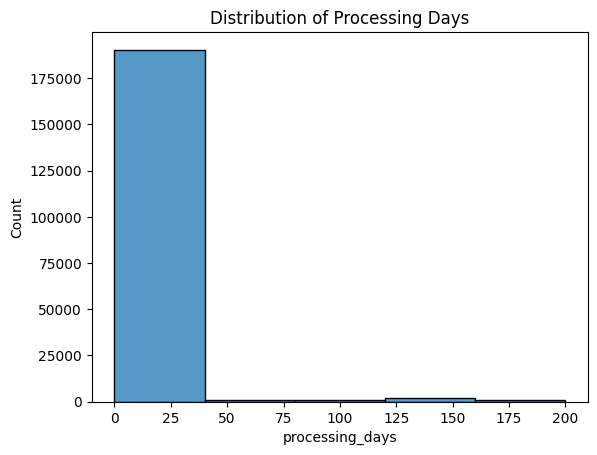

In [3]:
plt.figure()
sns.histplot(df['processing_days'], bins=5)

plt.title("Distribution of Processing Days")
plt.show()

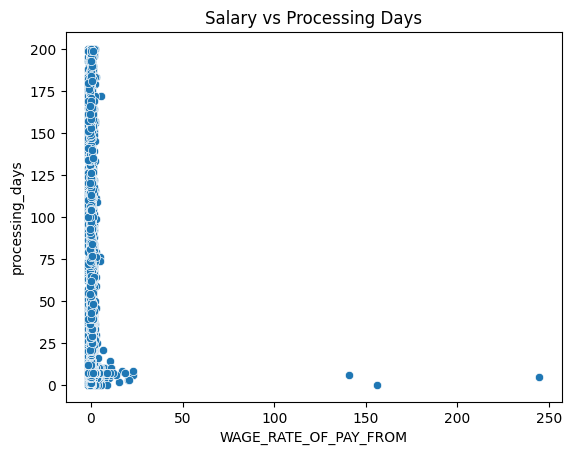

In [4]:
plt.figure()
sns.scatterplot(x='WAGE_RATE_OF_PAY_FROM', y='processing_days', data=df)

plt.title("Salary vs Processing Days")
plt.show()

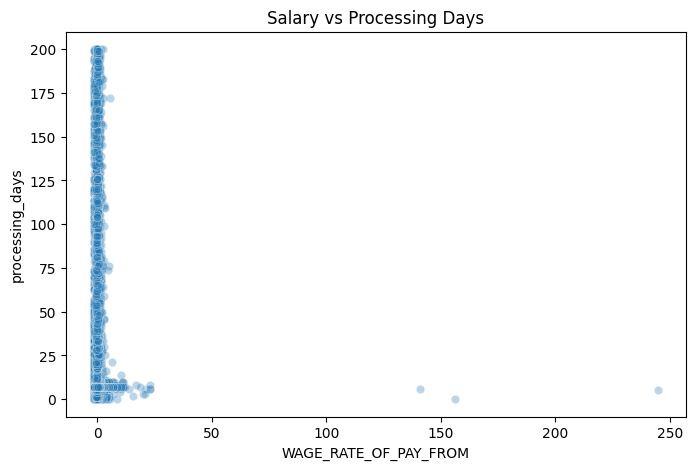

In [5]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='WAGE_RATE_OF_PAY_FROM',
    y='processing_days',
    data=df,
    alpha=0.3
)

plt.title("Salary vs Processing Days")
plt.show()

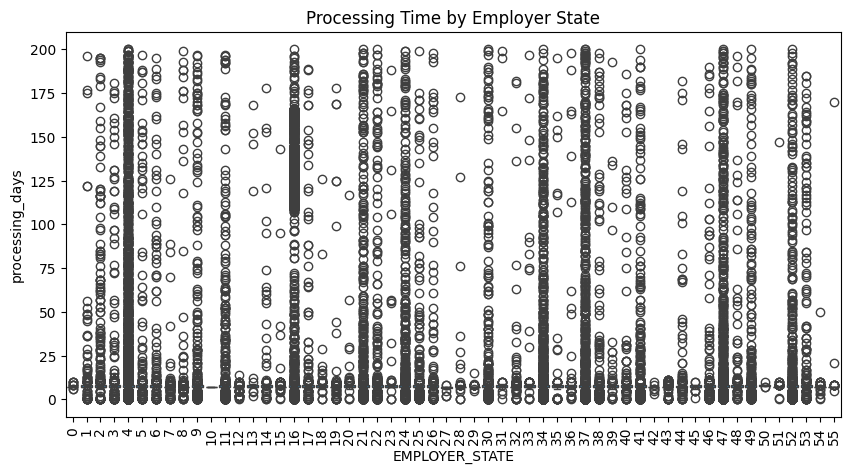

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(x='EMPLOYER_STATE', y='processing_days', data=df)

plt.xticks(rotation=90)

plt.title("Processing Time by Employer State")

plt.show()

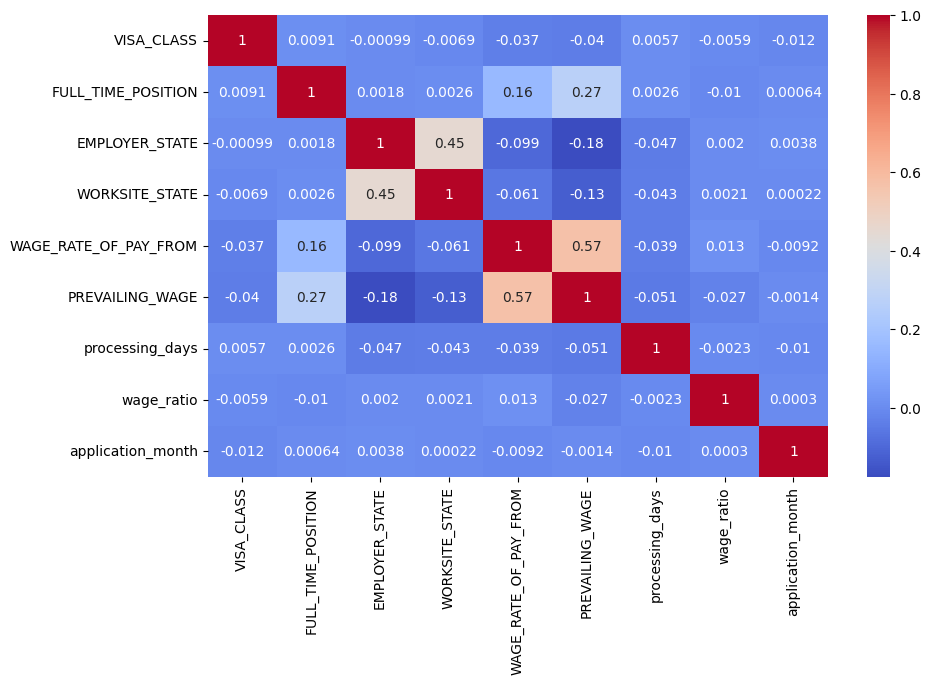

In [7]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6)) 
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [8]:
print("The correlation heatmap shows that most features have weak individual correlation with processing_days.\nThe strongest relationship is between CASE_STATUS and processing_days (0.36). \nAdditionally, WAGE_RATE_OF_PAY_FROM and PREVAILING_WAGE show strong correlation (0.58), indicating offered wages generally align with prevailing wage requirements.")

The correlation heatmap shows that most features have weak individual correlation with processing_days.
The strongest relationship is between CASE_STATUS and processing_days (0.36). 
Additionally, WAGE_RATE_OF_PAY_FROM and PREVAILING_WAGE show strong correlation (0.58), indicating offered wages generally align with prevailing wage requirements.


In [9]:
df['wage_ratio'] = df['WAGE_RATE_OF_PAY_FROM'] / df['PREVAILING_WAGE']

In [10]:
df.head()

,CASE_STATUS,VISA_CLASS,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month
0,Certified,1,1,34,10,-0.283237,-0.263317,5,1.075650,9
1,Certified,1,1,24,23,-0.735466,-1.052168,5,0.699000,9
2,Certified,1,1,9,20,-0.687250,-0.975133,5,0.704775,9
3,Certified,1,1,25,24,-0.735731,-1.110884,5,0.662294,9
4,Certified,1,1,47,45,-0.556892,-0.695744,5,0.800427,9


In [11]:
df_dates = pd.read_csv("dataset.csv", low_memory=False)

df['application_month'] = pd.to_datetime(df_dates['RECEIVED_DATE']).dt.month

In [12]:
state_avg = df.groupby('EMPLOYER_STATE')['processing_days'].transform('mean')

df['state_processing_avg'] = state_avg

In [13]:
df.head()

,CASE_STATUS,VISA_CLASS,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month,state_processing_avg
0,Certified,1,1,34,10,-0.283237,-0.263317,5,1.075650,9,8.305479
1,Certified,1,1,24,23,-0.735466,-1.052168,5,0.699000,9,9.646314
2,Certified,1,1,9,20,-0.687250,-0.975133,5,0.704775,9,8.897912
3,Certified,1,1,25,24,-0.735731,-1.110884,5,0.662294,9,9.010886
4,Certified,1,1,47,45,-0.556892,-0.695744,5,0.800427,9,8.434844


In [14]:
df['worksite_processing_avg'] = df.groupby('WORKSITE_STATE')['processing_days'].transform('mean')

df[['processing_days',
    'wage_ratio',
    'application_month',
    'state_processing_avg',
    'worksite_processing_avg']].corr()

,processing_days,wage_ratio,application_month,state_processing_avg,worksite_processing_avg
processing_days,1.000000,0.000856,0.059422,0.262394,0.280683
wage_ratio,0.000856,1.000000,0.001577,-0.009328,-0.006405
application_month,0.059422,0.001577,1.000000,0.024692,0.029165
state_processing_avg,0.262394,-0.009328,0.024692,1.000000,0.485346
worksite_processing_avg,0.280683,-0.006405,0.029165,0.485346,1.000000


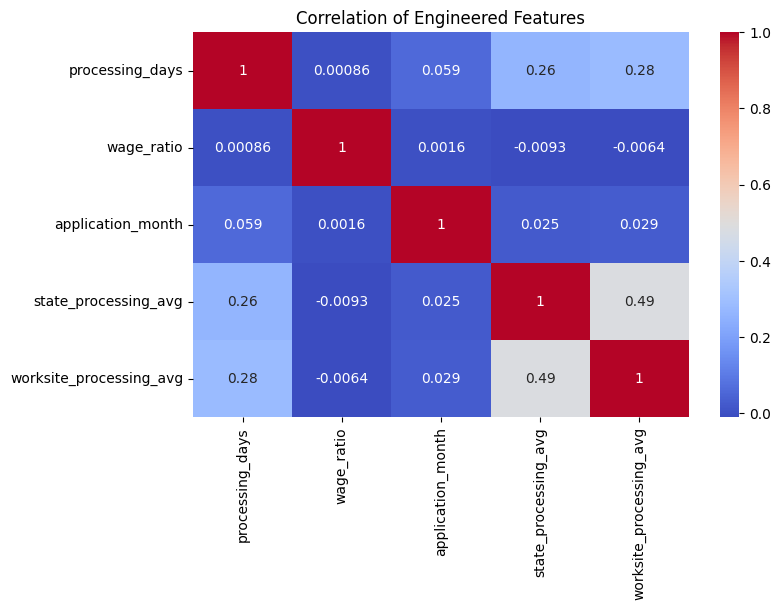

In [15]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['processing_days',
        'wage_ratio',
        'application_month',
        'state_processing_avg',
        'worksite_processing_avg']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Engineered Features")
plt.show()

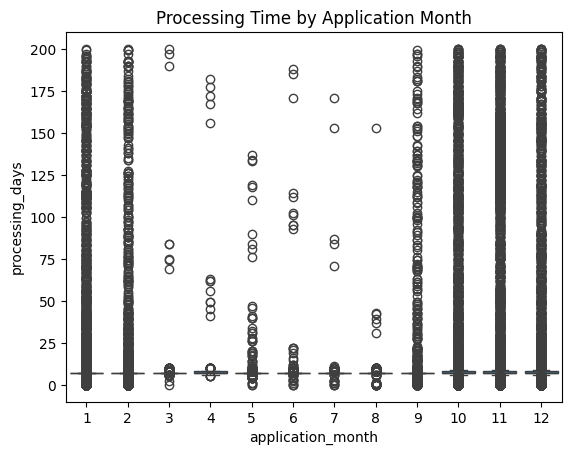

In [16]:
sns.boxplot(x='application_month', y='processing_days', data=df)

plt.title("Processing Time by Application Month")
plt.show()

In [17]:
print("The engineered features capturing regional processing trends (state_processing_avg and worksite_processing_avg) \nshow stronger correlation with processing time compared to wage-based features. \nThis suggests that geographic factors may influence visa processing duration more than salary-related attributes.")

The engineered features capturing regional processing trends (state_processing_avg and worksite_processing_avg) 
show stronger correlation with processing time compared to wage-based features. 
This suggests that geographic factors may influence visa processing duration more than salary-related attributes.


In [22]:
df.describe()
df.head()


,CASE_STATUS,VISA_CLASS,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month,state_processing_avg,worksite_processing_avg
0,Certified,1,1,34,10,-0.283237,-0.263317,5,1.075650,9,8.305479,8.551642
1,Certified,1,1,24,23,-0.735466,-1.052168,5,0.699000,9,9.646314,9.437536
2,Certified,1,1,9,20,-0.687250,-0.975133,5,0.704775,9,8.897912,9.385678
3,Certified,1,1,25,24,-0.735731,-1.110884,5,0.662294,9,9.010886,8.624650
4,Certified,1,1,47,45,-0.556892,-0.695744,5,0.800427,9,8.434844,8.420480


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194751 entries, 0 to 194750
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CASE_STATUS              194751 non-null  object 
 1   VISA_CLASS               194751 non-null  int64  
 2   FULL_TIME_POSITION       194751 non-null  int64  
 3   EMPLOYER_STATE           194751 non-null  int64  
 4   WORKSITE_STATE           194751 non-null  int64  
 5   WAGE_RATE_OF_PAY_FROM    194751 non-null  float64
 6   PREVAILING_WAGE          194751 non-null  float64
 7   processing_days          194751 non-null  int64  
 8   wage_ratio               194751 non-null  float64
 9   application_month        194751 non-null  int32  
 10  state_processing_avg     194751 non-null  float64
 11  worksite_processing_avg  194751 non-null  float64
dtypes: float64(5), int32(1), int64(5), object(1)
memory usage: 17.1+ MB


In [18]:
df.to_csv("cleaned_visa_feature_engineered_dataset.csv", index=False)
print("Milestone 2 Completed")

Milestone 2 Completed
